# Load data

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.preprocessing import MinMaxScaler
from graphviz import Digraph
import seaborn as sns
from matplotlib.ticker import MultipleLocator, FormatStrFormatter

train_set = pd.read_csv('data/train.csv')
features = ['laser energy', 'oxygen pressure', 'deposition_temp', 'TD_distance']
X = np.array(train_set[features])
x = train_set[features]
y = np.array(train_set['Jc_6'])

# Data distribution and normalization

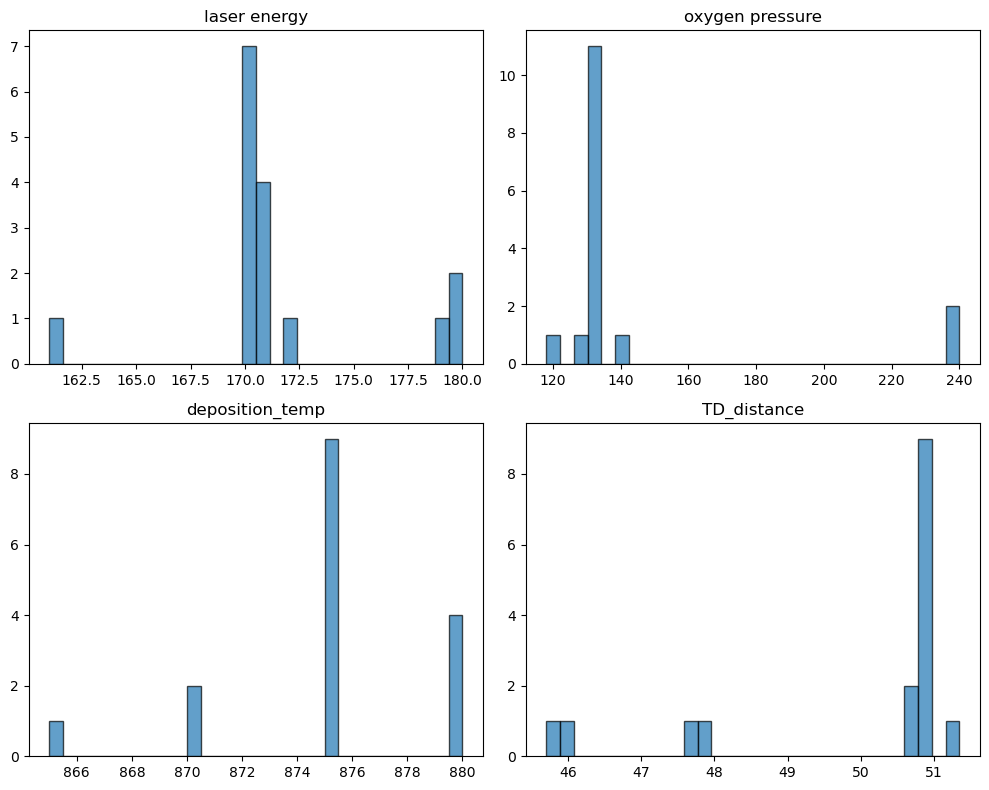

In [2]:
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)
X_train = X_normalized
y_train = train_set['Jc_6']

plt.figure(figsize=(10, 8))  # 设置图形大小
for i, predictor in enumerate(x.columns, 1):
    plt.subplot(2, 2, i)
    plt.hist(x[predictor], bins=30, alpha=0.7, edgecolor='black')
    plt.title(f'{predictor}') 

plt.tight_layout()
plt.show()

# Ob-Int CART model

In [3]:
# ==========================================================
# Tree Node
# ==========================================================

class TreeNode:

    def __init__(
            self,
            feature_idx=None,
            left_bound=None,
            right_bound=None,
            left=None,
            right=None,
            value=None,
            a_opt=None,
            combo_feat_idx=None,
            raw_candidate_feat=None,
            combo_expr=None
    ):

        self.feature_idx = feature_idx
        self.left_bound = left_bound
        self.right_bound = right_bound
        self.left = left
        self.right = right
        self.value = value
        self.a_opt = a_opt
        self.combo_feat_idx = combo_feat_idx
        self.raw_candidate_feat = raw_candidate_feat
        self.combo_expr = combo_expr

# ==========================================================
# CART
# ==========================================================

class CART:

    def __init__(
            self,
            task="regression",
            max_depth=4,
            min_samples_split=2,
            lambda_=0.1
    ):

        self.task = task
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.lambda_ = lambda_
        self.root = None
        self.init_n_features = None

    # ======================================================
    # impurity
    # ======================================================

    def _gini(self, y):
        if len(y) == 0:
            return 0
        counts = np.bincount(y.astype(int))
        probs = counts / len(y)
        return 1 - np.sum(probs ** 2)

    def _mse(self, y):
        if len(y) == 0:
            return 0
        return np.mean((y - np.mean(y)) ** 2)

    def _base_loss(self, y):
        return (
            self._gini(y)
            if self.task == "classification"
            else self._mse(y)
        )

    # ======================================================
    # split loss
    # ======================================================

    def _split_loss(self, y_in, y_out):
        n = len(y_in) + len(y_out)
        if self.task == "classification":
            return (
                len(y_in) * self._gini(y_in)
                + len(y_out) * self._gini(y_out)
            ) / n
        return (
            len(y_in) * self._mse(y_in)
            + len(y_out) * self._mse(y_out)
        ) / n

    # ======================================================
    # candidate interval
    # ======================================================

    def _get_candidate_bounds(self, values):
        values = np.unique(values)
        values.sort()
        if len(values) == 1:
            return values
        mids = (
            values[:-1]
            + values[1:]
        ) / 2
        return np.concatenate(
            (
                [values[0]],
                mids,
                [values[-1]]
            )
        )

    def _iter_intervals(self, bounds):
        n = len(bounds)
        for i in range(n):
            for j in range(i + 1, n):
                yield bounds[i], bounds[j]

    # ======================================================
    # linear combination
    # ======================================================

    def _get_linear_weights(
            self,
            X,
            y,
            candidate_feat,
            combo_feat_idx
    ):
        X_used = X[
            :,
            [combo_feat_idx, candidate_feat]
        ]
        ridge = Ridge(
            alpha=self.lambda_,
            fit_intercept=False
        )
        try:
            ridge.fit(X_used, y)
            return ridge.coef_
        except Exception:
            return None

    # ======================================================
    # projection
    # ======================================================

    def _generate_projection(
            self,
            X,
            feat_idx,
            combo_feat_idx,
            a_opt
    ):
        if a_opt is None:
            return X[:, feat_idx]
        return (
            X[
                :,
                [combo_feat_idx, feat_idx]
            ]
            @ a_opt
        )

    # ======================================================
    # dataset split
    # ======================================================

    def _split_dataset(
            self,
            scores,
            left_bound,
            right_bound
    ):
        in_mask = (
            (scores >= left_bound)
            &
            (scores <= right_bound)
        )
        return in_mask, ~in_mask

    # ======================================================
    # evaluate interval
    # ======================================================

    def _evaluate_projection(
            self,
            scores,
            y,
            base_loss
    ):
        best_gain = -np.inf
        best_left = None
        best_right = None
        bounds = self._get_candidate_bounds(scores)
        for left_bound, right_bound in self._iter_intervals(bounds):
            in_mask, out_mask = self._split_dataset(
                scores,
                left_bound,
                right_bound
            )
            y_in = y[in_mask]
            y_out = y[out_mask]
            if len(y_in) == 0 or len(y_out) == 0:
                continue
            loss = self._split_loss(
                y_in,
                y_out
            )
            gain = base_loss - loss
            if gain > best_gain:
                best_gain = gain
                best_left = left_bound
                best_right = right_bound
        return (
            best_gain,
            best_left,
            best_right
        )

    # ======================================================
    # leaf value
    # ======================================================

    def _leaf_value(self, y):
        if self.task == "classification":
            return np.argmax(
                np.bincount(y.astype(int))
            )
        return np.mean(y)

    # ======================================================
    # append combo feature
    # ======================================================

    def _append_combo_feat(
            self,
            X,
            proj_scores
    ):
        X_new = np.hstack(
            [
                X,
                proj_scores.reshape(-1, 1)
            ]
        )

        return (
            X_new,
            X_new.shape[1] - 1
        )
    # ======================================================
    # best split
    # ======================================================

    def _best_split(
            self,
            X,
            y,
            depth,
            remaining_raw_features,
            latest_combo_feat_idx
    ):

        n_samples, n_features = X.shape
        base_loss = self._base_loss(y)
        best_gain = -np.inf
        best_feature_idx = None
        best_left_bound = None
        best_right_bound = None
        best_a_opt = None

        # --------------------------------------------------
        # depth = 0
        # --------------------------------------------------

        if depth == 0:
            candidate_list = []
            for feat_idx in range(self.init_n_features):
                candidate_list.append(
                    (
                        feat_idx,
                        X[:, feat_idx],
                        None
                    )
                )

        # --------------------------------------------------
        # depth >= 1
        # --------------------------------------------------

        else:
            if (
                latest_combo_feat_idx is None
                or latest_combo_feat_idx >= n_features
                or len(remaining_raw_features) == 0
            ):
                return (
                    None,
                    None,
                    None,
                    None
                )
            candidate_list = []
            for feat_idx in remaining_raw_features:
                a_opt = self._get_linear_weights(
                    X,
                    y,
                    feat_idx,
                    latest_combo_feat_idx
                )
                if a_opt is None:
                    continue
                proj_scores = self._generate_projection(
                    X,
                    feat_idx,
                    latest_combo_feat_idx,
                    a_opt
                )
                candidate_list.append(
                    (
                        feat_idx,
                        proj_scores,
                        a_opt
                    )
                )

        # --------------------------------------------------
        # evaluate candidates
        # --------------------------------------------------

        for (
                feat_idx,
                proj_scores,
                a_opt
        ) in candidate_list:
            (
                gain,
                left_bound,
                right_bound
            ) = self._evaluate_projection(
                proj_scores,
                y,
                base_loss
            )
            if gain > best_gain:
                best_gain = gain
                best_feature_idx = feat_idx
                best_left_bound = left_bound
                best_right_bound = right_bound
                best_a_opt = a_opt
        return (
            best_feature_idx,
            best_left_bound,
            best_right_bound,
            best_a_opt
        )
        
    # ======================================================
    # build tree
    # ======================================================

    def _build_tree(
            self,
            X,
            y,
            depth,
            remaining_raw_features,
            latest_combo_feat_idx
    ):
        n_samples = len(y)
        
        # --------------------------------------------------
        # stop condition
        # --------------------------------------------------

        if (
            depth >= self.max_depth
            or n_samples < self.min_samples_split
            or self._base_loss(y) < 1e-6
        ):
            return TreeNode(
                value=self._leaf_value(y)
            )

        # --------------------------------------------------
        # best split
        # --------------------------------------------------

        (
            feat_idx,
            left_bound,
            right_bound,
            a_opt
        ) = self._best_split(
            X,
            y,
            depth,
            remaining_raw_features,
            latest_combo_feat_idx
        )

        if feat_idx is None:
            return TreeNode(
                value=self._leaf_value(y)
            )

        # --------------------------------------------------
        # projection score
        # --------------------------------------------------

        proj_scores = self._generate_projection(
            X,
            feat_idx,
            latest_combo_feat_idx,
            a_opt
        )

        # --------------------------------------------------
        # split dataset
        # --------------------------------------------------

        in_mask, out_mask = self._split_dataset(
            proj_scores,
            left_bound,
            right_bound
        )
        X_in = X[in_mask]
        y_in = y[in_mask]
        X_out = X[out_mask]
        y_out = y[out_mask]
        if len(y_in) == 0 or len(y_out) == 0:
            return TreeNode(
                value=self._leaf_value(y)
            )

        # --------------------------------------------------
        # append new combo feature
        # --------------------------------------------------

        X_in_new, combo_idx_in = self._append_combo_feat(
            X_in,
            proj_scores[in_mask]
        )
        X_out_new, combo_idx_out = self._append_combo_feat(
            X_out,
            proj_scores[out_mask]
        )

        # --------------------------------------------------
        # remaining raw feature
        # --------------------------------------------------

        remaining_raw = [
            f
            for f in remaining_raw_features
            if f != feat_idx
        ]

        # --------------------------------------------------
        # current node
        # --------------------------------------------------

        current_node = TreeNode(
            feature_idx=feat_idx,
            left_bound=left_bound,
            right_bound=right_bound,
            a_opt=a_opt,
            combo_feat_idx=latest_combo_feat_idx,
            raw_candidate_feat=feat_idx
        )

        # --------------------------------------------------
        # recursion
        # --------------------------------------------------

        current_node.left = self._build_tree(
            X_in_new,
            y_in,
            depth + 1,
            remaining_raw,
            combo_idx_in
        )
        current_node.right = self._build_tree(
            X_out_new,
            y_out,
            depth + 1,
            remaining_raw,
            combo_idx_out
        )
        return current_node
        
    # ======================================================
    # fit
    # ======================================================

    def fit(self, X, y):
        X = np.asarray(
            X,
            dtype=np.float64
        )
        y = np.asarray(y)
        self.init_n_features = X.shape[1]
        self.root = self._build_tree(
            X,
            y,
            depth=0,
            remaining_raw_features=list(
                range(self.init_n_features)
            ),
            latest_combo_feat_idx=None
        )
        return self

    # ======================================================
    # predict one sample
    # ======================================================

    def _predict_sample(
            self,
            x,
            node,
            current_depth=0
    ):
        if node.value is not None:
            return (
                node.value,
                current_depth
            )
        feat_idx = node.feature_idx
        left_bound = node.left_bound
        right_bound = node.right_bound
        a_opt = node.a_opt
        combo_feat_idx = node.combo_feat_idx

        # ----------------------------------------------
        # projection
        # ----------------------------------------------

        if a_opt is None:
            proj_score = x[feat_idx]
        else:
            proj_score = (
                np.array(
                    [
                        x[combo_feat_idx],
                        x[feat_idx]
                    ]
                )
                @ a_opt
            )

        # ----------------------------------------------
        # append new combo feature
        # ----------------------------------------------

        x_new = np.hstack(
            [
                x,
                [proj_score]
            ]
        )

        # ----------------------------------------------
        # branch
        # ----------------------------------------------

        next_node = (
            node.left
            if left_bound <= proj_score <= right_bound
            else node.right
        )

        return self._predict_sample(
            x_new,
            next_node,
            current_depth + 1
        )

    # ======================================================
    # predict
    # ======================================================

    def predict(
            self,
            X,
            return_depth=False
    ):
        X = np.asarray(
            X,
            dtype=np.float64
        )
        results = [
            self._predict_sample(
                x,
                self.root
            )
            for x in X
        ]
        y_pred = np.array(
            [
                r[0]
                for r in results
            ]
        )
        depths = [
            r[1]
            for r in results
        ]
        if return_depth:
            return y_pred, depths
        return y_pred

    # ======================================================
    # depth vs mse
    # ======================================================

    def get_depth_vs_pred_mse(
            self,
            X,
            y,
            by_leaf_depth=False,
            max_depth_target=10
    ):
        if self.task != "regression":
            raise ValueError(
                "Only regression task supports MSE."
            )
        X = np.asarray(X)
        y = np.asarray(y)

        # ----------------------------------------------
        # leaf depth
        # ----------------------------------------------

        if by_leaf_depth:
            y_pred, depths = self.predict(
                X,
                return_depth=True
            )
            result = {
                "depth": [],
                "mse": []
            }
            for depth in sorted(
                    set(depths)
            ):
                idx = [
                    i
                    for i, d in enumerate(depths)
                    if d == depth
                ]
                mse = mean_squared_error(
                    y[idx],
                    y_pred[idx]
                )
                result["depth"].append(depth)
                result["mse"].append(
                    round(mse, 6)
                )
            return result

        # ----------------------------------------------
        # max_depth
        # ----------------------------------------------

        result = {
            "depth": [],
            "mse": []
        }
        for depth in range(
                1,
                max_depth_target + 1
        ):
            model = CART(
                task="regression",
                max_depth=depth,
                min_samples_split=self.min_samples_split,
                lambda_=self.lambda_
            )
            model.fit(
                X,
                y
            )
            pred = model.predict(X)
            mse = mean_squared_error(
                y,
                pred
            )
            result["depth"].append(depth)
            result["mse"].append(
                round(mse, 6)
            )
        return result

    # ======================================================
    # graph utils
    # ======================================================

    def _get_next_node_id(self):
        node_id = self._node_id_counter
        self._node_id_counter += 1
        return f"node_{node_id}"

    # ======================================================
    # graph recursion
    # ======================================================

    def _recursive_build_graph(
            self,
            dot,
            node,
            current_node_id,
            feature_names
    ):

        # ----------------------------------------------
        # leaf
        # ----------------------------------------------

        if node.value is not None:
            dot.node(
                current_node_id,
                label=f"prediction:{round(node.value,4)}",
                shape="ellipse",
                style="filled",
                fillcolor="#e6f7e6"
            )
            return
        interval = (
            f"[{round(node.left_bound,4)}, "
            f"{round(node.right_bound,4)}]"
        )
        def feat_name(idx):
            if idx < len(feature_names):
                return feature_names[idx]
            return f"f{idx}"

        # ----------------------------------------------
        # node label
        # ----------------------------------------------

        if node.a_opt is None:
            label = (
                f"{feat_name(node.feature_idx)} "
                f"in {interval}"
            )
        else:
            w1 = round(node.a_opt[0], 4)
            w2 = round(node.a_opt[1], 4)
            label = (
                f"{w1}*{feat_name(node.combo_feat_idx)}"
                f"+"
                f"{w2}*{feat_name(node.feature_idx)}"
                f"\n"
                f"in {interval}"
            )
        dot.node(
            current_node_id,
            label=label,
            shape="box",
            style="filled",
            fillcolor="#e6f3ff"
        )
        # ----------------------------------------------
        # left
        # ----------------------------------------------

        left_id = self._get_next_node_id()
        dot.edge(
            current_node_id,
            left_id,
            label="in interval"
        )
        self._recursive_build_graph(
            dot,
            node.left,
            left_id,
            feature_names
        )

        # ----------------------------------------------
        # right
        # ----------------------------------------------

        right_id = self._get_next_node_id()
        dot.edge(
            current_node_id,
            right_id,
            label="out of interval"
        )
        self._recursive_build_graph(
            dot,
            node.right,
            right_id,
            feature_names
        )

    # ======================================================
    # plot tree
    # ======================================================

    def plot_tree(
            self,
            save_path="cart_tree",
            format="pdf",
            feature_names=None
    ):
        if self.root is None:
            raise ValueError(
                "Please fit model first."
            )
        if feature_names is None:
            feature_names = [
                f"f{i}"
                for i in range(
                    self.init_n_features
                )
            ]
        dot = Digraph(
            comment="Oblique Interval Tree",
            format=format
        )
        dot.attr(
            rankdir="TB",
            dpi="300"
        )
        self._node_id_counter = 0
        root_id = self._get_next_node_id()
        self._recursive_build_graph(
            dot,
            self.root,
            root_id,
            feature_names
        )
        dot.render(
            save_path,
            view=False,
            cleanup=True
        )
        print(
            f"Tree saved:"
            f" {save_path}.{format}"
        )
        return None
        
    # ======================================================
    # plot depth vs rmse
    # ======================================================
    def depth_vs_rmse(
            self,
            X,
            y,
            max_depth_target=4,
    ):
        result = self.get_depth_vs_pred_mse(
            X,
            y,
            by_leaf_depth=False,
            max_depth_target=max_depth_target
        )
        depths = result["depth"]
        rmses = np.sqrt(
            np.array(result["mse"])
        )
        return {
            "depth": depths,
            "rmse": rmses
        }         

# Leave-one-out cross validation

In [18]:
min_samples_split_vals = [2, 3, 4, 5]
lambda_vals = np.linspace(0.05,1.0,96)

best_score = np.inf
best_params = None

# ------------------------------
# LOOCV (grid search)
# ------------------------------
n = len(X)
print(f"data size: {n}, {n} folds LOOCV")

for min_split in min_samples_split_vals:
    for lam in lambda_vals:
        errors = []
        for i in range(n):
            train_X = np.delete(X, i, axis=0)
            train_y = np.delete(y, i, axis=0)
            X_val = X[i].reshape(1, -1)
            y_val = y[i]
            scaler = MinMaxScaler()
            X_train_normalized = scaler.fit_transform(train_X)
            X_val_scaled = scaler.transform(X_val)
            model = CART(
                task="regression",
                max_depth=4,
                min_samples_split=min_split, 
                lambda_=lam, 
            )
            model.fit(X_train_normalized, train_y)
            y_pred = model.predict(X_val_scaled)
            errors.append(np.sqrt((y_val - y_pred) ** 2))
        loocv_rmse = np.mean(errors)
        print(f"min_child_weight={min_split:3d}, reg_lambda={lam:5.2f} -> LOOCV_RMSE={loocv_rmse:.4f}")
        if loocv_rmse  < best_score:
            best_score = loocv_rmse 
            best_params = {'min_samples_split': min_split, 'lambda_': lam}

# ------------------------------
# print results
# ------------------------------
print("\n========== best hyperparameters ==========")
print(f"min_samples_split: {best_params['min_samples_split']}")
print(f"lambda_: {best_params['lambda_']}")
print(f"best LOOCV RMSE: {best_score:.4f}")

data size: 16, 16 folds LOOCV
min_child_weight=  2, reg_lambda= 0.05 -> LOOCV_RMSE=0.2229
min_child_weight=  2, reg_lambda= 0.06 -> LOOCV_RMSE=0.2279
min_child_weight=  2, reg_lambda= 0.07 -> LOOCV_RMSE=0.2130
min_child_weight=  2, reg_lambda= 0.08 -> LOOCV_RMSE=0.2231
min_child_weight=  2, reg_lambda= 0.09 -> LOOCV_RMSE=0.2278
min_child_weight=  2, reg_lambda= 0.10 -> LOOCV_RMSE=0.2087
min_child_weight=  2, reg_lambda= 0.11 -> LOOCV_RMSE=0.2271
min_child_weight=  2, reg_lambda= 0.12 -> LOOCV_RMSE=0.2155
min_child_weight=  2, reg_lambda= 0.13 -> LOOCV_RMSE=0.2079
min_child_weight=  2, reg_lambda= 0.14 -> LOOCV_RMSE=0.2166
min_child_weight=  2, reg_lambda= 0.15 -> LOOCV_RMSE=0.2139
min_child_weight=  2, reg_lambda= 0.16 -> LOOCV_RMSE=0.2114
min_child_weight=  2, reg_lambda= 0.17 -> LOOCV_RMSE=0.2107
min_child_weight=  2, reg_lambda= 0.18 -> LOOCV_RMSE=0.2102
min_child_weight=  2, reg_lambda= 0.19 -> LOOCV_RMSE=0.1961
min_child_weight=  2, reg_lambda= 0.20 -> LOOCV_RMSE=0.2115
min_child_

# Train and plot tree

In [19]:
Ob_Int_CART = CART(
    task="regression", 
    max_depth=4, 
    min_samples_split=best_params['min_samples_split'], 
    lambda_=best_params['lambda_'])
Ob_Int_CART.fit(X_train, y_train)
Ob_Int_CART.plot_tree(
    save_path = "Ob_Int_CART",
    feature_names=[
        "E",
        "P",
        "T",
        "D"
    ]
)

Tree saved: Ob_Int_CART.pdf


# Comparison with the base CART

In [20]:
# ==========================================================
# Tree Node
# ==========================================================

class TreeNode_base:

    def __init__(
            self,
            feature_idx=None,
            threshold=None,
            left=None,
            right=None,
            value=None
    ):
        self.feature_idx = feature_idx
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value


# ==========================================================
# CART Regression
# ==========================================================

class CART_base:

    def __init__(
            self,
            max_depth=4,
            min_samples_split=2
    ):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None

    # ======================================================
    # mse
    # ======================================================

    def _mse(self, y):

        if len(y) == 0:
            return 0

        return np.mean(
            (y - np.mean(y)) ** 2
        )

    # ======================================================
    # leaf value
    # ======================================================

    def _leaf_value(self, y):

        return np.mean(y)

    # ======================================================
    # candidate thresholds
    # ======================================================

    def _candidate_thresholds(
            self,
            values
    ):

        values = np.unique(values)

        if len(values) <= 1:
            return []

        return (
            values[:-1]
            + values[1:]
        ) / 2

    # ======================================================
    # best split
    # ======================================================

    def _best_split(
            self,
            X,
            y
    ):

        best_gain = -np.inf

        best_feature = None
        best_threshold = None

        parent_mse = self._mse(y)

        n = len(y)

        n_features = X.shape[1]

        for feat_idx in range(n_features):

            thresholds = self._candidate_thresholds(
                X[:, feat_idx]
            )

            for threshold in thresholds:

                left_mask = (
                    X[:, feat_idx]
                    <= threshold
                )

                right_mask = ~left_mask

                if (
                        np.sum(left_mask) == 0
                        or
                        np.sum(right_mask) == 0
                ):
                    continue

                y_left = y[left_mask]
                y_right = y[right_mask]

                split_mse = (
                        len(y_left)
                        * self._mse(y_left)
                        +
                        len(y_right)
                        * self._mse(y_right)
                ) / n

                gain = (
                    parent_mse
                    - split_mse
                )

                if gain > best_gain:

                    best_gain = gain

                    best_feature = feat_idx

                    best_threshold = threshold
        if best_gain <= 0:
            return None, None
        return (
            best_feature,
            best_threshold
        )

    # ======================================================
    # build tree
    # ======================================================

    def _build_tree(
            self,
            X,
            y,
            depth
    ):

        n_samples = len(y)

        if (
                depth >= self.max_depth
                or
                n_samples < self.min_samples_split
                or
                self._mse(y) < 1e-12
        ):

            return TreeNode_base(
                value=self._leaf_value(y)
            )

        feature_idx, threshold = (
            self._best_split(
                X,
                y
            )
        )

        if feature_idx is None:

            return TreeNode_base(
                value=self._leaf_value(y)
            )

        left_mask = (
            X[:, feature_idx]
            <= threshold
        )

        right_mask = ~left_mask

        if (
                np.sum(left_mask) == 0
                or
                np.sum(right_mask) == 0
        ):

            return TreeNode_base(
                value=self._leaf_value(y)
            )

        left_child = self._build_tree(
            X[left_mask],
            y[left_mask],
            depth + 1,
        )

        right_child = self._build_tree(
            X[right_mask],
            y[right_mask],
            depth + 1,
        )

        return TreeNode_base(
            feature_idx=feature_idx,
            threshold=threshold,
            left=left_child,
            right=right_child
        )

    # ======================================================
    # fit
    # ======================================================

    def fit(
            self,
            X,
            y
    ):

        X = np.asarray(
            X,
            dtype=float
        )

        y = np.asarray(
            y,
            dtype=float
        )

        self.n_features_ = X.shape[1]

        self.root = self._build_tree(
            X,
            y,
            depth=0
        )

        return self

    # ======================================================
    # predict sample
    # ======================================================

    def _predict_sample(
            self,
            x,
            node
    ):

        if node.value is not None:
            return node.value

        if (
                x[node.feature_idx]
                <= node.threshold
        ):
            return self._predict_sample(
                x,
                node.left
            )

        return self._predict_sample(
            x,
            node.right
        )

    # ======================================================
    # predict
    # ======================================================

    def predict(
            self,
            X
    ):

        X = np.asarray(
            X,
            dtype=float
        )

        return np.array(
            [
                self._predict_sample(
                    x,
                    self.root
                )
                for x in X
            ]
        )

    # ======================================================
    # RMSE vs Depth
    # ======================================================
    def depth_vs_rmse(
            self,
            X,
            y,
            max_depth_target=4
    ):
        depths = []
        rmse_list = []
        for depth in range(
                1,
                max_depth_target + 1
        ):
            model = CART_base(
                max_depth=depth,
                min_samples_split=self.min_samples_split
            )
            model.fit(
                X,
                y
            )
            pred = model.predict(X)
            rmse = np.sqrt(
                mean_squared_error(
                    y,
                    pred
                )
            )
            rmse_list.append(rmse)
            depths.append(depth)
        return {
            "depth": depths,
            "rmse": rmse_list
        }
        
    # ======================================================
    # graphviz
    # ======================================================

    def _graph(
            self,
            dot,
            node,
            node_id
    ):

        if node.value is not None:

            dot.node(
                node_id,
                f"Pred={node.value:.4f}",
                shape="ellipse"
            )

            return

        label = (
            f"X[{node.feature_idx}]"
            f"\n<= {node.threshold:.4f}"
        )

        dot.node(
            node_id,
            label,
            shape="box"
        )

        left_id = node_id + "L"
        right_id = node_id + "R"

        dot.edge(
            node_id,
            left_id,
            "True"
        )

        dot.edge(
            node_id,
            right_id,
            "False"
        )

        self._graph(
            dot,
            node.left,
            left_id
        )

        self._graph(
            dot,
            node.right,
            right_id
        )

    def plot_tree(
            self,
            save_path="cart_tree",
            format="pdf"
    ):

        dot = Digraph(
            format=format
        )

        self._graph(
            dot,
            self.root,
            "root"
        )

        dot.render(
            save_path,
            cleanup=True
        )

        print(
            f"Saved to {save_path}.{format}"
        )
        return None

In [21]:
min_samples_split_vals = [1, 2, 3, 4, 5, 6, 7, 8]
best_score_base = np.inf
best_params = None
# ------------------------------
# LOOCV (grid search)
# ------------------------------
n = len(X)
print(f"data size: {n}, {n} folds LOOCV")

for min_split in min_samples_split_vals:
    errors = []
    for i in range(n):
        train_X = np.delete(X, i, axis=0)
        train_y = np.delete(y, i, axis=0)
        X_val = X[i].reshape(1, -1)
        y_val = y[i]
        scaler = MinMaxScaler()
        X_train_normalized = scaler.fit_transform(train_X)
        X_val_scaled = scaler.transform(X_val)
        model = CART_base(
            max_depth=4,
            min_samples_split=min_split, 
        )
        model.fit(X_train_normalized, train_y)
        y_pred = model.predict(X_val_scaled)
        errors.append(np.sqrt((y_val - y_pred) ** 2))
    loocv_rmse = np.mean(errors)
    print(f"min_child_weight={min_split:3d} -> LOOCV_RMSE={loocv_rmse:.4f}")
    if loocv_rmse < best_score_base:
        best_score_base = loocv_rmse
        best_params = {'min_samples_split': min_split}
# ------------------------------
# print results
# ------------------------------
print("\n========== best hyperparameters ==========")
print(f"min_samples_split: {best_params['min_samples_split']}")
print(f"best LOOCV RMSE: {best_score_base:.4f}")

data size: 16, 16 folds LOOCV
min_child_weight=  1 -> LOOCV_RMSE=0.2076
min_child_weight=  2 -> LOOCV_RMSE=0.2076
min_child_weight=  3 -> LOOCV_RMSE=0.2082
min_child_weight=  4 -> LOOCV_RMSE=0.2055
min_child_weight=  5 -> LOOCV_RMSE=0.2177
min_child_weight=  6 -> LOOCV_RMSE=0.2195
min_child_weight=  7 -> LOOCV_RMSE=0.2269
min_child_weight=  8 -> LOOCV_RMSE=0.2205

========== best hyperparameters ==========
min_samples_split: 4
best LOOCV RMSE: 0.2055


In [22]:
model_base = CART_base(
    max_depth=4,
    min_samples_split=best_params['min_samples_split']
)
model_base.fit(X_train, y_train)
model.plot_tree()

Saved to cart_tree.pdf
